#GluonTS Quick Start

This tutorial can be found [here](https://ts.gluon.ai/stable/tutorials/forecasting/quick_start_tutorial.html#).

GluonTS contains:

* A number of pre-built models
* Components for building new models (likelihoods, feature processing pipelines, calendar features etc.)
* Data loading and processing
* Plotting and evaluation facilities
* Artificial and real datasets (only external datasets with blessed license)

Import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

## Datasets

### Provided datasets

GluonTS comes with a number of publicly available datasets.

In [2]:
from gluonts.dataset.repository import get_dataset, dataset_names
from gluonts.dataset.util import to_pandas

c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Display avaliable datasets

In [3]:
print(f"Available datasets: {dataset_names}")

Available datasets: ['constant', 'exchange_rate', 'solar-energy', 'electricity', 'traffic', 'exchange_rate_nips', 'electricity_nips', 'traffic_nips', 'solar_nips', 'wiki2000_nips', 'wiki-rolling_nips', 'taxi_30min', 'kaggle_web_traffic_with_missing', 'kaggle_web_traffic_without_missing', 'kaggle_web_traffic_weekly', 'm1_yearly', 'm1_quarterly', 'm1_monthly', 'nn5_daily_with_missing', 'nn5_daily_without_missing', 'nn5_weekly', 'tourism_monthly', 'tourism_quarterly', 'tourism_yearly', 'cif_2016', 'london_smart_meters_without_missing', 'wind_farms_without_missing', 'car_parts_without_missing', 'dominick', 'fred_md', 'pedestrian_counts', 'hospital', 'covid_deaths', 'kdd_cup_2018_without_missing', 'weather', 'm3_monthly', 'm3_quarterly', 'm3_yearly', 'm3_other', 'm4_hourly', 'm4_daily', 'm4_weekly', 'm4_monthly', 'm4_quarterly', 'm4_yearly', 'm5', 'uber_tlc_daily', 'uber_tlc_hourly', 'airpassengers', 'australian_electricity_demand', 'electricity_hourly', 'electricity_weekly', 'rideshare_wit

To download one of the built-in datasets, simply call the `get_dataset()` method with one of the above names. GluonTS can re-use the saved dataset so that it does not need to be downloaded again the next time it's used.

In [4]:
dataset = get_dataset("m4_hourly")

In general, the datasets provided by GluonTS are objects that consists of three main members:

- `dataset.train` - an iterable collection of data entries used for training.
  - Each entry corresponds to one time series.
- `dataset.test` - an iterable collection of data entries used for inference.
  - The test dataset is an extended version of the train dataset and contains a window in the end of each time series that was not seen during training.
  - This window has a length equal to the recommended prediction length.
- `dataset.metadata` - contains metadata about the dataset e.g. the frequency of the time series, a recommended prediction horizon, associated features, etc.

c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\dataset\common.py:263: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Period(val, freq)


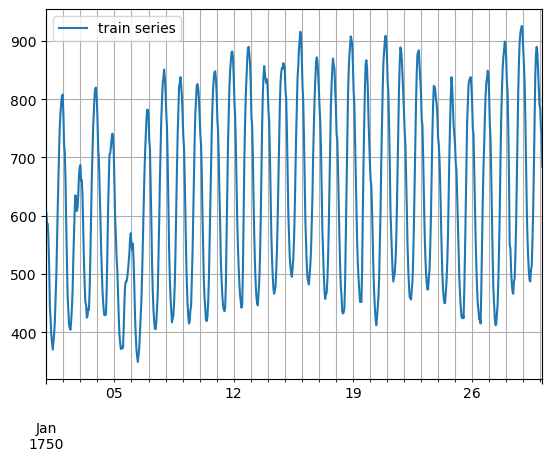

In [5]:
# get starting point for iterating through training set
entry = next(iter(dataset.train))

# convert training set to pandas series
train_series = to_pandas(entry)

# plot training set
train_series.plot()
plt.grid(which="both")
plt.legend(["train series"], loc="upper left")
plt.show()

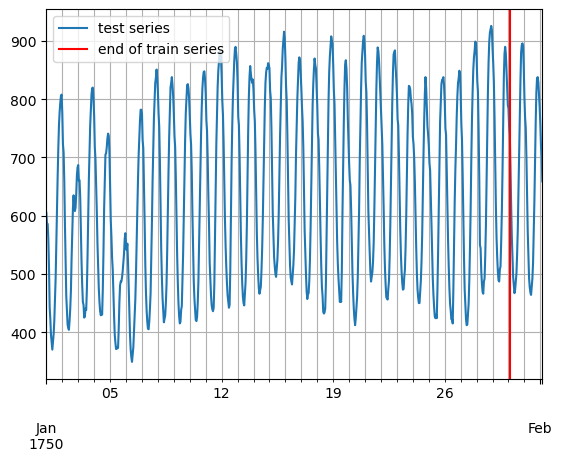

In [6]:
# get starting point for iterating through test set
entry = next(iter(dataset.test))

# convert test set into pandas series
test_series = to_pandas(entry)

# plot test set
test_series.plot()
plt.axvline(train_series.index[-1], color="r")  # end of train dataset
plt.grid(which="both")
plt.legend(["test series", "end of train series"], loc="upper left")
plt.show()

In [7]:
window_length = len(test_series) - len(train_series)
print(f"Length of forecasting window in test dataset: {window_length}")
print(f"Recommended prediction horizon: {dataset.metadata.prediction_length}")
print(f"Frequency of the time series: {dataset.metadata.freq}")

Length of forecasting window in test dataset: 48
Recommended prediction horizon: 48
Frequency of the time series: H


### Custom datasets

At this point, it is important to emphasize that GluonTS does not require this specific format for a custom dataset that a user may have. The only requirements for a custom dataset are

- be iterable
- and have a "target" and a "start" field.
  
To make this more clear, assume the common case where a dataset is in the form of a `numpy.array` and the index of the time series in a `pandas.Period` (possibly different for each time series):

In [8]:
N = 10  # number of time series
T = 100  # number of timesteps
prediction_length = 24
freq = "1H"
custom_dataset = np.random.normal(size=(N, T))
start = pd.Period("01-01-2019", freq=freq)  # can be different for each time series

C:\Users\Mike\AppData\Local\Temp\ipykernel_19716\2007592095.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = pd.Period("01-01-2019", freq=freq)  # can be different for each time series


Now, you can split your dataset and bring it in a GluonTS appropriate format with just two lines of code:

In [9]:
from gluonts.dataset.common import ListDataset

In [10]:
# train dataset: cut the last window of length "prediction_length", add "target" and "start" fields
train_ds = ListDataset(
    [{"target": x, "start": start} for x in custom_dataset[:, :-prediction_length]],  # get the first prediction_length values 
    freq=freq,
)

# test dataset: use the whole dataset, add "target" and "start" fields
test_ds = ListDataset(
    [{"target": x, "start": start} for x in custom_dataset], freq=freq
)

c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\dataset\common.py:255: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ProcessDataEntry(to_offset(freq), one_dim_target, use_timestamp),


## Training an existing model (`Estimator`)

GluonTS comes with a number of pre-built models. All the user needs to do is configure some hyperparameters. The existing models focus on (but are not limited to) probabilistic forecasting. Probabilistic forecasts are predictions in the form of a probability distribution, rather than simply a single point estimate.

We will begin with GluonTS's pre-built feedforward neural network estimator, a simple but powerful forecasting model. We will use this model to demonstrate the process of training a model, producing forecasts, and evaluating the results.

GluonTS's built-in feedforward neural network (`SimpleFeedForwardEstimator`) accepts an input window of length `context_length` and predicts the distribution of the values of the subsequent `prediction_length` values. In GluonTS parlance, the feedforward neural network model is an example of an `Estimator`. In GluonTS, `Estimator` objects represent a forecasting model as well as details such as its coefficients, weights, etc.

In general, each estimator (pre-built or custom) is configured by a number of hyperparameters that can be either common (but not binding) among all estimators (e.g., the `prediction_length`) or specific for the particular estimator (e.g., number of layers for a neural network or the stride in a CNN).

In [11]:
from gluonts.torch import SimpleFeedForwardEstimator

In [12]:
estimator = SimpleFeedForwardEstimator(
    hidden_dimensions=[10],
    prediction_length=dataset.metadata.prediction_length,
    context_length=100,
)

After specifying our estimator with all the necessary hyperparameters we can train it using our training dataset `dataset.train` by invoking the `train` method of the estimator. The training algorithm returns a fitted model (or a `Predictor` in GluonTS parlance) that can be used to construct forecasts.

In [13]:
predictor = estimator.train(dataset.train)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: 
  | Name  | Type                   | Params | Mode 
---------------------------------------------------------
0 | model | SimpleFeedForwardModel | 48.5 K | train
---------------------------------------------------------
48.5 K    Trainable params
0         Non-trainabl

Epoch 0: |          | 50/? [00:00<00:00, 52.61it/s, v_num=2, train_loss=5.630]

INFO: Epoch 0, global step 50: 'train_loss' reached 5.63348 (best 5.63348), saving model to 'c:\\Users\\Mike\\vscode\\TEMPO_prob\\gluonts\\lightning_logs\\version_2\\checkpoints\\epoch=0-step=50.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 50: 'train_loss' reached 5.63348 (best 5.63348), saving model to 'c:\\Users\\Mike\\vscode\\TEMPO_prob\\gluonts\\lightning_logs\\version_2\\checkpoints\\epoch=0-step=50.ckpt' as top 1


Epoch 1: |          | 50/? [00:00<00:00, 68.34it/s, v_num=2, train_loss=5.120]

...

Epoch 98: |          | 50/? [00:00<00:00, 52.40it/s, v_num=2, train_loss=4.390]

INFO: Epoch 98, global step 4950: 'train_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 98, global step 4950: 'train_loss' was not in top 1


Epoch 99: |          | 50/? [00:01<00:00, 48.01it/s, v_num=2, train_loss=4.480]

INFO: Epoch 99, global step 5000: 'train_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 99, global step 5000: 'train_loss' was not in top 1
INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: |          | 50/? [00:01<00:00, 47.63it/s, v_num=2, train_loss=4.480]


## Visualize and evaluate forecasts

With a predictor in hand, we can now predict the last window of the `dataset.test` and evaluate our model's performance.

GluonTS comes with the `make_evaluation_predictions()` function that automates the process of prediction and model evaluation. Roughly, this function performs the following steps:

- Removes the final window of length `prediction_length` of the `dataset.test` that we want to predict
- The estimator uses the remaining data to predict (in the form of sample paths) the "future" window that was just removed
- The module outputs the forecast sample paths and the `dataset.test` (as python generator objects)

In [14]:
from gluonts.evaluation import make_evaluation_predictions

In [15]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=dataset.test,  # test dataset
    predictor=predictor,  # predictor
    num_samples=100,  # number of sample paths we want for evaluation
)

First, we can convert these generators to lists to ease the subsequent computations.

In [16]:
forecasts = list(forecast_it)
tss = list(ts_it)

We can examine the first element of these lists (that corresponds to the first time series of the dataset). Let's start with the list containing the time series, i.e., `tss`. We expect the first entry of `tss` to contain the (target of the) first time series of `dataset.test`.

In [17]:
# first entry of the time series list
ts_entry = tss[0]

In [18]:
# first 5 values of the time series (convert from pandas to numpy)
np.array(ts_entry[:5]).reshape(
    -1,
)

array([605., 586., 586., 559., 511.], dtype=float32)

In [19]:
# first entry of dataset.test
dataset_test_entry = next(iter(dataset.test))

In [20]:
# first 5 values
dataset_test_entry["target"][:5]

array([605., 586., 586., 559., 511.], dtype=float32)

The entries in the `forecast` list are a bit more complex. They are objects that contain all the sample paths in the form of `numpy.ndarray` with dimension `(num_samples, prediction_length)`, the start date of the forecast, the frequency of the time series, etc. We can access all this information by simply invoking the corresponding attribute of the forecast object.

In [21]:
# first entry of the forecast list
forecast_entry = forecasts[0]

In [22]:

# ! these print statements cause the program to fail
# print(f"Number of sample paths: {forecast_entry.num_samples}")
# print(f"Dimension of samples: {forecast_entry.samples.shape}")
# print(f"Start date of the forecast window: {forecast_entry.start_date}")
# print(f"Frequency of the time series: {forecast_entry.freq}")

We can also do calculations to summarize the sample paths, such as computing the mean or a quantile for each of the 48 time steps in the forecast window.

In [23]:
print(f"Mean of the future window:\n {forecast_entry.mean}")
print(f"0.5-quantile (median) of the future window:\n {forecast_entry.quantile(0.5)}")

Mean of the future window:
 [621.01746 566.66046 543.74384 521.1121  499.65662 439.18915 472.802
 487.6949  496.94385 561.08856 576.24384 663.98444 749.2201  811.69916
 862.1185  850.03955 867.1171  837.3041  822.75995 829.0826  772.96484
 758.78827 712.79315 664.48206 635.3848  592.2571  539.07294 495.1853
 450.38065 445.35257 467.75745 488.7808  491.9253  513.96747 580.4531
 644.89557 724.3498  785.23553 828.01154 824.4121  857.99115 879.9525
 837.5466  806.5947  788.1101  750.31586 719.2409  721.9203 ]
0.5-quantile (median) of the future window:
 [621.01746 566.66046 543.74384 521.1121  499.65662 439.18915 472.802
 487.6949  496.94385 561.08856 576.24384 663.98444 749.2201  811.69916
 862.1185  850.03955 867.1171  837.3041  822.75995 829.0826  772.96484
 758.78827 712.79315 664.48206 635.3848  592.2571  539.07294 495.1853
 450.38065 445.35257 467.75745 488.7808  491.9253  513.96747 580.4531
 644.89557 724.3498  785.23553 828.01154 824.4121  857.99115 879.9525
 837.5466  806.5947  78

`Forecast` objects have a `plot` method that can summarize the forecast paths as the mean, prediction intervals, etc. The prediction intervals are shaded in different colors as a "fan chart".

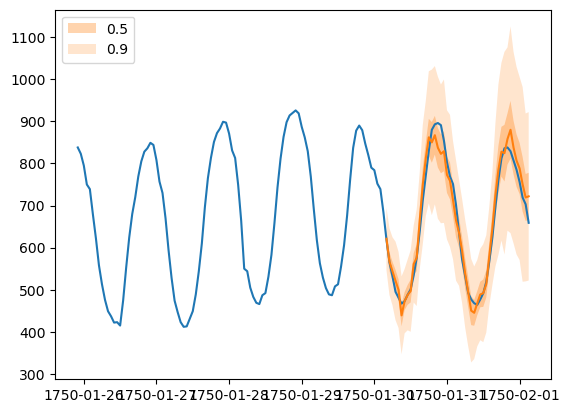

In [24]:
plt.plot(ts_entry[-150:].to_timestamp())
forecast_entry.plot(show_label=True)
plt.legend()

We can also evaluate the quality of our forecasts numerically. In GluonTS, the `Evaluator` class can compute aggregate performance metrics, as well as metrics per time series (which can be useful for analyzing performance across heterogeneous time series).

In [25]:
from gluonts.evaluation import Evaluator

In [26]:
evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])
agg_metrics, item_metrics = evaluator(tss, forecasts)

Running evaluation: 414it [00:03, 136.32it/s]


The aggregate metrics, `agg_metrics`, aggregate both across time-steps and across time series.

In [27]:
print(json.dumps(agg_metrics, indent=4))

{
    "MSE": 1899386.820394376,
    "abs_error": 5740207.7698946,
    "abs_target_sum": 145558863.59960938,
    "abs_target_mean": 7324.822041043146,
    "seasonal_error": 336.9046924038305,
    "MASE": 2.7690629868421444,
    "MAPE": 0.1716171007981335,
    "sMAPE": 0.15505572606699958,
    "MSIS": 51.096663083772334,
    "num_masked_target_values": 0.0,
    "QuantileLoss[0.1]": 4331203.415433885,
    "Coverage[0.1]": 0.08368558776167473,
    "QuantileLoss[0.5]": 5740207.80771637,
    "Coverage[0.5]": 0.3233192431561997,
    "QuantileLoss[0.9]": 4919174.267584132,
    "Coverage[0.9]": 0.8560789049919485,
    "RMSE": 1378.1824336401826,
    "NRMSE": 0.1881523436225233,
    "ND": 0.039435645675857035,
    "wQuantileLoss[0.1]": 0.029755683084664506,
    "wQuantileLoss[0.5]": 0.03943564593569535,
    "wQuantileLoss[0.9]": 0.03379508568516561,
    "mean_absolute_QuantileLoss": 4996861.830244795,
    "mean_wQuantileLoss": 0.03432880490184182,
    "MAE_Coverage": 0.38535963499731624,
    "OW

Individual metrics are aggregated only across time-steps.

In [28]:
item_metrics.head()

,item_id,forecast_start,MSE,abs_error,abs_target_sum,abs_target_mean,seasonal_error,MASE,MAPE,sMAPE,num_masked_target_values,ND,MSIS,QuantileLoss[0.1],Coverage[0.1],QuantileLoss[0.5],Coverage[0.5],QuantileLoss[0.9],Coverage[0.9]
0,0,1750-01-30 04:00,755.706950,1055.601562,31644.0,659.250000,42.371302,0.519023,0.031803,0.031686,0.0,0.033359,10.109590,858.591650,0.000000,1055.601593,0.625000,944.031744,1.000000
1,1,1750-01-30 04:00,80352.645833,12653.910156,124149.0,2586.437500,165.107988,1.596671,0.108460,0.101765,0.0,0.101925,11.256967,2034.743652,0.187500,12653.910400,1.000000,6441.574072,1.000000
2,2,1750-01-30 04:00,36550.312500,7535.688477,65030.0,1354.791667,78.889053,1.990054,0.105988,0.113908,0.0,0.115880,10.792975,3296.705347,0.000000,7535.688660,0.020833,2353.805908,0.687500
3,3,1750-01-30 04:00,225418.041667,18305.382812,235783.0,4912.145833,258.982249,1.472542,0.073364,0.075263,0.0,0.077637,11.619230,8224.868457,0.000000,18305.382080,0.333333,5429.656445,0.916667
4,4,1750-01-30 04:00,59284.770833,8219.978516,131088.0,2731.000000,200.494083,0.854138,0.058315,0.056248,0.0,0.062706,10.343185,3395.663501,0.020833,8219.978027,0.562500,5344.157983,1.000000


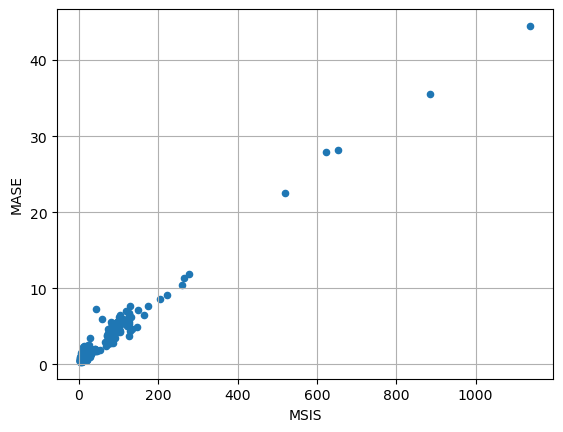

In [29]:
item_metrics.plot(x="MSIS", y="MASE", kind="scatter")
plt.grid(which="both")
plt.show()